### Load Prepared Data

In [1]:
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

feature_train = pd.read_csv('X_train_prepared.csv', index_col=0)
target_train = pd.read_csv('y_train_prepared.csv', index_col=0).squeeze()
feature_test = pd.read_csv('X_test_processed.csv', index_col=0)
target_test = pd.read_csv('y_test.csv', index_col=0).squeeze()

### Train the Regression Tree

In [2]:
rt_model = DecisionTreeRegressor(
    max_depth=5,
    min_samples_leaf=10,
    random_state=42
)
rt_model.fit(feature_train, target_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_lea

### Predictions

In [3]:
y_pred_train = rt_model.predict(feature_train)
y_pred_test  = rt_model.predict(feature_test)

### Evaluation Metrics

In [4]:
mae  = mean_absolute_error(target_test, y_pred_test)
rmse = np.sqrt(mean_squared_error(target_test, y_pred_test))
r2   = r2_score(target_test, y_pred_test)

print(f"MAE:  {mae:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"R²:   {r2:.4f}")

MAE:  71.2746
RMSE: 90.7188
R²:   0.9013


### Predicted vs Actual Plot

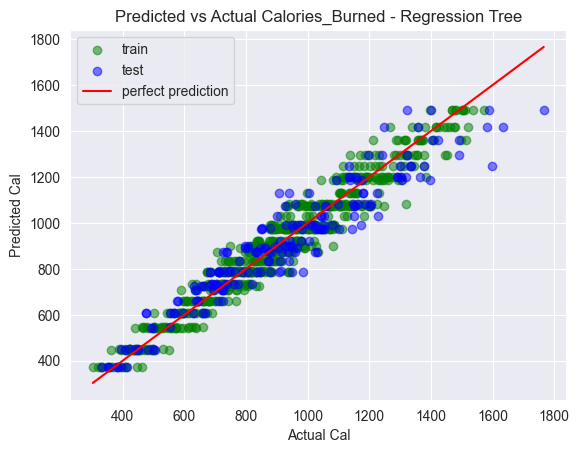

In [5]:
min_val = min(target_train.min(), target_test.min())
max_val = max(target_train.max(), target_test.max())

plt.scatter(target_train, y_pred_train, c='green', label='train', alpha=0.5)
plt.scatter(target_test,  y_pred_test,  c='blue',  label='test',  alpha=0.5)
plt.plot([min_val, max_val], [min_val, max_val], c='red', label='perfect prediction')

plt.xlabel('Actual Cal')
plt.ylabel('Predicted Cal')
plt.legend()
plt.title('Predicted vs Actual Calories_Burned - Regression Tree')
plt.show()

### Train vs Test R² (Overfitting Check)

In [6]:
r2_train = r2_score(target_train, y_pred_train)
r2_test  = r2_score(target_test, y_pred_test)

print(f"R² on train: {r2_train:.4f}")
print(f"R² on test:  {r2_test:.4f}")

R² on train: 0.9431
R² on test:  0.9013


### Feature Importances

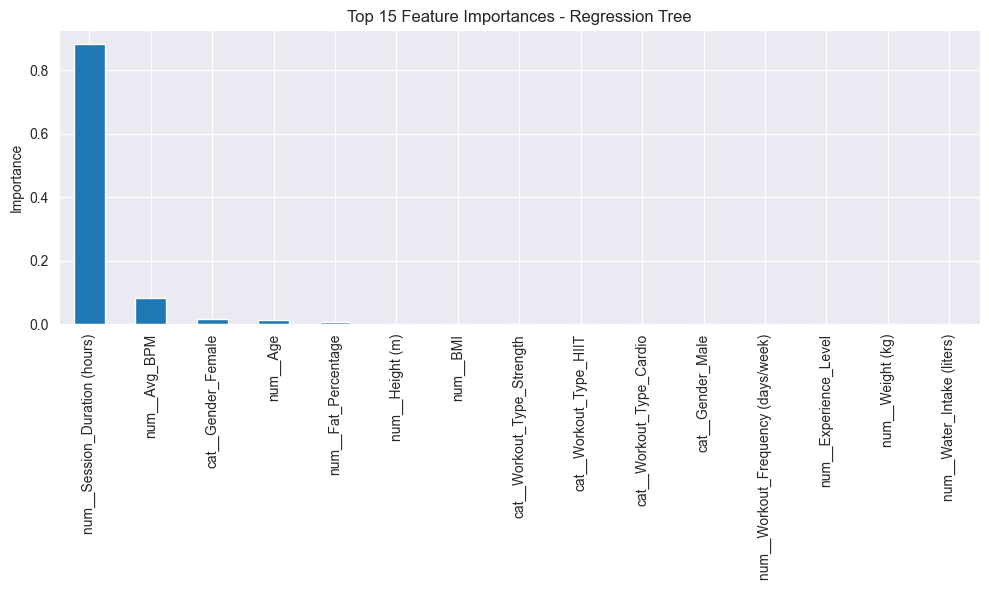

In [7]:
importances = pd.Series(rt_model.feature_importances_, index=feature_train.columns)
importances = importances.sort_values(ascending=False).head(15)

plt.figure(figsize=(10, 6))
importances.plot(kind='bar')
plt.title('Top 15 Feature Importances - Regression Tree')
plt.ylabel('Importance')
plt.tight_layout()
plt.show()

### Visualize the Tree

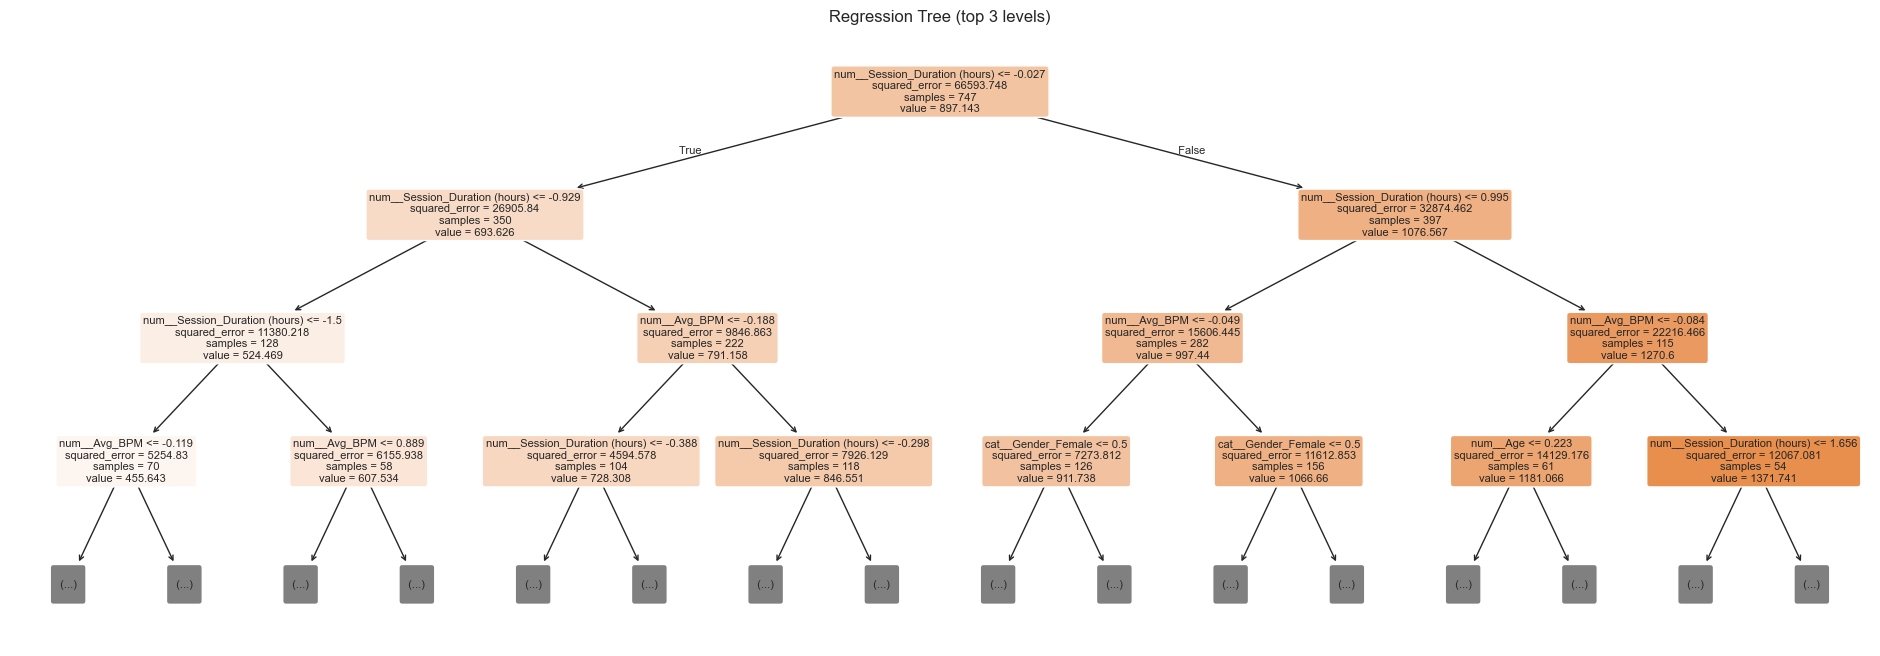

In [8]:
plt.figure(figsize=(24, 8))
plot_tree(
    rt_model,
    feature_names=feature_train.columns.tolist(),
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)
plt.title('Regression Tree (top 3 levels)')
plt.show()